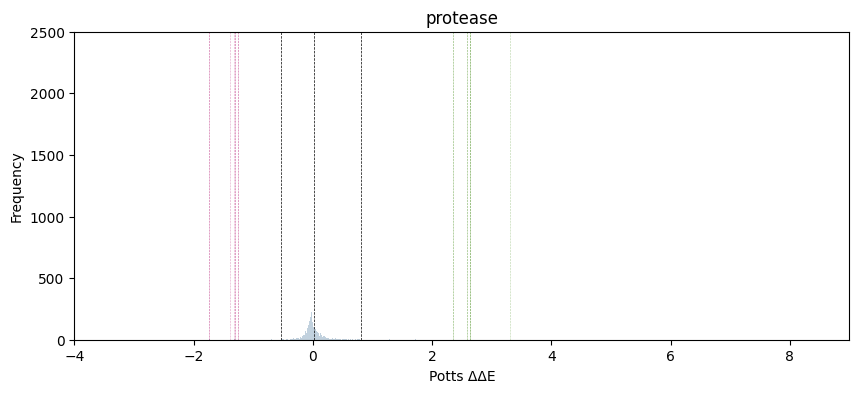

In [19]:
# Initialize dictionaries to store delta E and delta delta E values
import collections
import re


delta_e_per_position = collections.defaultdict(lambda: [0.0, 0.0, 0.0, 0.0])
delta_delta_e_per_pair = []

# Define mutation_map to map amino acids to indices
mutation_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

# Read the file and process the data
with open('data/rt.alldde') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        columns = re.split(r'[,\t\s]+', line)
        mutations = columns[0]
        ddE = float(columns[1])
        delta_e1 = float(columns[3])
        delta_e2 = float(columns[4])
        
        # Extract positions from the mutation string
        positions = [int(pos) for pos in re.findall(r'\d+', mutations)]
        if len(positions) != 2:
            continue
        
        pos1, pos2 = positions
        
        #detect the wildtype 'first' aa seuqnce, and put A' delta e into [0]....D's delta e into [3]
        # Store delta E values for each position
        # Detect the wildtype 'first' amino acid sequence
        wildtype_aa1 = mutations[0]  # Extract the first amino acid from the mutation string
        wildtype_aa2 = mutations.split('-')[1][0]  # Extract the first letter after '-'
        mutate_aa1 = mutations[mutations.index('-') - 1]  # Extract the one letter before '-'
        mutate_aa2 = mutations[-1]
        # print(f"Processing mutation: {mutations}, Positions: {pos1}, {pos2}, Wildtype AAs: {wildtype_aa1}, {wildtype_aa2}, Mutated AA1: {mutate_aa1}, Mutated AA2: {mutate_aa2}")
        # Map the wildtype amino acid to the corresponding index in the delta_e_per_position list
        if mutate_aa1 in mutation_map:
            delta_e_per_position[pos1][mutation_map[mutate_aa1]] = delta_e1
        if mutate_aa2 in mutation_map:
            delta_e_per_position[pos2][mutation_map[mutate_aa2]] = delta_e2
        
        # Store delta delta E values for each pair of positions
        delta_delta_e_per_pair.append((pos1, pos2, ddE))

        # Print out the content in delta_delta_e_per_pair

##################plot###################################
import matplotlib.pyplot as plt
import numpy as np

# Extract ddE values from delta_delta_e_per_pair
ddE_values = [pair[2] for pair in delta_delta_e_per_pair]

# Create a figure with the desired size
plt.figure(figsize=(10,4))

# Plot the histogram
plt.hist(ddE_values, bins=1000, color='#c1d1de')
plt.xlabel('Potts ΔΔE')
plt.ylabel('Frequency')
plt.xlim(-4, 9)
plt.title('protease')
plt.ylim(0, 2500)

# Calculate the 5th and 95th percentiles
percentile_neg = np.percentile(ddE_values, 1)
mean_ddE = np.mean(ddE_values)
percentile_pos = np.percentile(ddE_values, 99)

# Add black dashed lines for the percentiles
plt.axvline(percentile_neg, color='black', linestyle='--', linewidth=0.5, label='5th Percentile')
plt.axvline(percentile_pos, color='black', linestyle='--', linewidth=0.5, label='95th Percentile')

# Add a red dashed line for the mean
plt.axvline(mean_ddE, color='black', linestyle='--', linewidth=0.5, label='Mean')


percentile_top_neg = np.percentile(ddE_values, 0.1)
percentile_top_pos = np.percentile(ddE_values, 99.9)


# Calculate the top negative and positive percentiles
top_neg_values = [value for value in ddE_values if value <= percentile_top_neg]
top_pos_values = [value for value in ddE_values if value >= percentile_top_pos]

# Add red dashed lines for all top negative values with transparency
for value in top_neg_values:
    plt.axvline(value, color='#b3126f', linestyle='--', linewidth=0.4, alpha=0.4)

# Add green dashed lines for all top positive values with transparency
for value in top_pos_values:
    plt.axvline(value, color='#4b901f', linestyle='--', linewidth=0.4, alpha=0.4)



# Add legend
# plt.legend()

plt.show()


C:\Users\xuech\AppData\Local\Temp\ipykernel_33660\3505812780.py:140: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr_r')


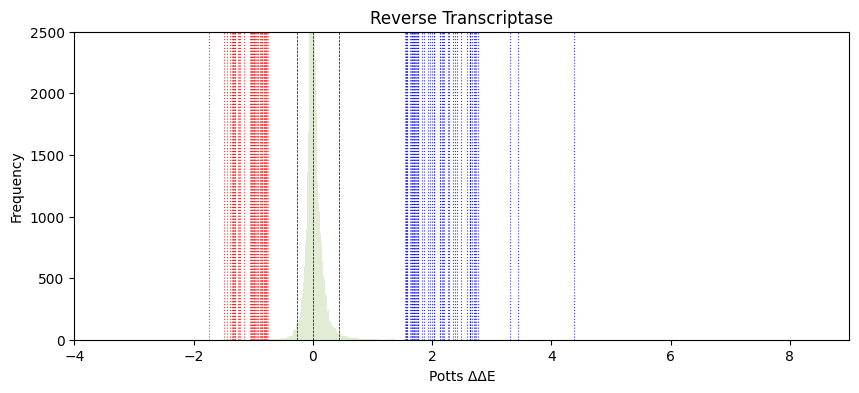

In [20]:
# Initialize dictionaries to store delta E and delta delta E values
import collections
import re


delta_e_per_position = collections.defaultdict(lambda: [0.0, 0.0, 0.0, 0.0])
delta_delta_e_per_pair = []

# Define mutation_map to map amino acids to indices
mutation_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

# Read the file and process the data
with open('data/kn.her2.all') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        columns = re.split(r'[,\t\s]+', line)
        mutations = columns[0]
        ddE = float(columns[1])
        delta_e1 = float(columns[3])
        delta_e2 = float(columns[4])
        
        # Extract positions from the mutation string
        positions = [int(pos) for pos in re.findall(r'\d+', mutations)]
        if len(positions) != 2:
            continue
        
        pos1, pos2 = positions
        
        #detect the wildtype 'first' aa seuqnce, and put A' delta e into [0]....D's delta e into [3]
        # Store delta E values for each position
        # Detect the wildtype 'first' amino acid sequence
        wildtype_aa1 = mutations[0]  # Extract the first amino acid from the mutation string
        wildtype_aa2 = mutations.split('-')[1][0]  # Extract the first letter after '-'
        mutate_aa1 = mutations[mutations.index('-') - 1]  # Extract the one letter before '-'
        mutate_aa2 = mutations[-1]
        # print(f"Processing mutation: {mutations}, Positions: {pos1}, {pos2}, Wildtype AAs: {wildtype_aa1}, {wildtype_aa2}, Mutated AA1: {mutate_aa1}, Mutated AA2: {mutate_aa2}")
        # Map the wildtype amino acid to the corresponding index in the delta_e_per_position list
        if mutate_aa1 in mutation_map:
            delta_e_per_position[pos1][mutation_map[mutate_aa1]] = delta_e1
        if mutate_aa2 in mutation_map:
            delta_e_per_position[pos2][mutation_map[mutate_aa2]] = delta_e2
        
        # Store delta delta E values for each pair of positions
        delta_delta_e_per_pair.append((pos1, pos2, ddE))

        # Print out the content in delta_delta_e_per_pair

delta_delta_e_per_pair_sorted = sorted(delta_delta_e_per_pair, key=lambda x: x[-1], reverse=True)
# Ensure pos1 is always less than pos2
delta_delta_e_per_pair_sorted = [
    (min(pos1, pos2), max(pos1, pos2), dde) for pos1, pos2, dde in delta_delta_e_per_pair_sorted
]

drug_resistant_positions = [
    184, 65, 70, 74, 115, 41, 67, 70, 210, 215, 219, 69, 151,  # NRTI positions
    100, 101, 103, 106, 138, 181, 188, 190, 230  # NNRTI positions
]
dde_drug_resistant_background = [
    pair for pair in delta_delta_e_per_pair_sorted
    if pair[0] in drug_resistant_positions or pair[1] in drug_resistant_positions
]

synergistic_drug_resistant_pairs = [
    pair for pair in delta_delta_e_per_pair_sorted
        if (pair[0], pair[1]) in [
        (116, 151), (101, 190), (41, 215), (101, 190), (75, 132), (103, 225),
        (70, 219), (100, 103), (67, 219), (101, 103), (70, 219), (181, 221),
        (210, 215), (103, 190), (116, 151), (103, 225), (65, 68), (100, 103),
        (75, 77), (108, 221), (41, 215), (103, 192), (67, 219), (100, 103),
        (210, 215), (101, 138), (41, 215), (181, 190), (67, 70), (103, 177),
        (74, 115), (108, 189), (74, 100), (101, 138), (62, 75), (138, 190),
        (116, 151), (101, 192), (62, 75), (108, 109)
        ]
]
antagonistic_drug_resistant_pairs = [    
    pair for pair in delta_delta_e_per_pair_sorted
    if (pair[0], pair[1]) in [
        (65, 215), (100, 181), (67, 118), (103, 179), (74, 75), (108, 188),
        (210, 214), (103, 190), (65, 215), (103, 190), (74, 77), (100, 190),
        (41, 46), (101, 103), (74, 75), (100, 101), (74, 116), (138, 181),
        (210, 219), (100, 108), (70, 210), (221, 223), (74, 151), (103, 188),
        (41, 214), (181, 188), (74, 116), (101, 103), (67, 118), (188, 190),
        (74, 75), (108, 190), (70, 210), (101, 181), (65, 67), (103, 181),
        (74, 151), (100, 106), (184, 188), (181, 225)
    ]
]

##################plot###################################
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

anta_max = -1.16
syner_min = 1.76
# Extract ddE values from delta_delta_e_per_pair
ddE_values_dr = [pair[2] for pair in dde_drug_resistant_background]
ddE_values = [pair[2] for pair in delta_delta_e_per_pair_sorted]
# Create a figure with the desired size
plt.figure(figsize=(10,4))

# Plot the histogram
plt.hist(ddE_values, bins=1000, color='#e2ecd4')
plt.xlabel('Potts ΔΔE')
plt.ylabel('Frequency')
plt.xlim(-4, 9)
plt.title('Reverse Transcriptase')
plt.ylim(0, 2500)

# Calculate the 5th and 95th percentiles
percentile_neg = np.percentile(ddE_values, 1)
mean_ddE = np.mean(ddE_values)
percentile_pos = np.percentile(ddE_values, 99)

# Add black dashed lines for the percentiles
plt.axvline(percentile_neg, color='black', linestyle='--', linewidth=0.5, label='5th Percentile')
plt.axvline(percentile_pos, color='black', linestyle='--', linewidth=0.5, label='95th Percentile')

# Add a red dashed line for the mean
plt.axvline(mean_ddE, color='black', linestyle='--', linewidth=0.5, label='Mean')


# Define the top and bottom cutoff numbers
top_cutoff = 50  # Number of top positive values
bottom_cutoff = 50  # Number of top negative values

# Sort ddE_values_dr in descending order
sorted_ddE_values_dr = sorted(ddE_values_dr, reverse=True)

# Extract the top positive and top negative values based on the cutoff
top_pos_values = sorted_ddE_values_dr[:top_cutoff]
top_neg_values = sorted_ddE_values_dr[-bottom_cutoff:]

# Add red dashed lines for all top negative values with transparency
# Define normalization and colormap
norm = Normalize(vmin=anta_max, vmax=syner_min)
cmap = cm.get_cmap('bwr_r')

# Add red dashed lines for all top negative values with transparency
for value in top_neg_values:
    color = cmap(norm(value))
    plt.axvline(value, color=color, linestyle=':', linewidth=0.8, alpha=0.8)

# Add blue dashed lines for all top positive values with transparency
for value in top_pos_values:
    color = cmap(norm(value))
    plt.axvline(value, color=color, linestyle=':', linewidth=0.8, alpha=0.8)



# Add legend
# plt.legend()

plt.show()
